Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 4), (2, 4), (3, 4), (4, 4)]


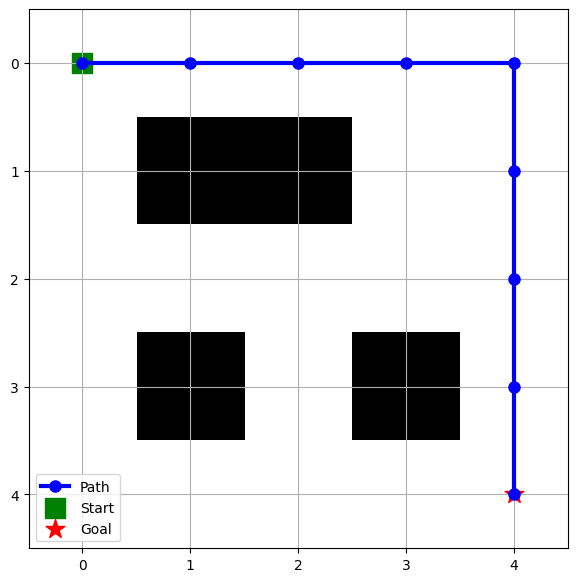

In [2]:
import heapq
import matplotlib.pyplot as plt

grid=[
    [0,0,0,0,0],
    [0,1,1,0,0],
    [0,0,0,0,0],
    [0,1,0,1,0],
    [0,0,0,0,0]
]

start = (0,0)
goal = (4,4)


def heuristic(a,b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])


def astar(grid,start,goal):

    rows = len(grid)
    cols = len(grid[0])

    open_list=[]

    heapq.heappush(open_list,(0,start))

    came_from={}
    g_score = {start:0}

    f_score = {
        start: heuristic(start,goal)
    }

    directions = [
        (-1,0),
        (1,0),
        (0,-1),
        (0,1)
    ]

    while open_list:

        current = heapq.heappop(open_list)[1]

        if current == goal:

            path=[]

            while current in came_from:
                path.append(current)
                current = came_from[current]

            path.append(start)
            path.reverse()

            return path

        r,c = current

        for dr,dc in directions:

            nr = r + dr
            nc = c + dc

            if(
                0 <= nr < rows
                and 0 <= nc < cols
                and grid[nr][nc] == 0
            ):

                neighbor = (nr,nc)

                tentative_g_score = g_score[current] + 1

                if tentative_g_score < g_score.get(
                    neighbor,float("inf")
                ):

                    came_from[neighbor] = current

                    g_score[neighbor] = tentative_g_score

                    f = (
                        tentative_g_score +
                        heuristic(neighbor,goal)
                    )

                    f_score[neighbor] = f

                    heapq.heappush(
                        open_list,
                        (f,neighbor)
                    )

    return None


path = astar(grid,start,goal)

print("Path:",path)


def visualize_grid(grid,path,start,goal):

    plt.figure(figsize=(7,7))

    plt.imshow(
        grid,
        cmap="gray_r",
        origin="upper"
    )

    if path:

        x = [p[1] for p in path]
        y = [p[0] for p in path]

        plt.plot(
            x,
            y,
            color="blue",
            linewidth=3,
            marker="o",
            markersize=8,
            label="Path"
        )

    plt.scatter(
        start[1],
        start[0],
        color="green",
        s=200,
        marker="s",
        label="Start"
    )

    plt.scatter(
        goal[1],
        goal[0],
        color="red",
        s=200,
        marker="*",
        label="Goal"
    )

    plt.xticks(range(len(grid[0])))
    plt.yticks(range(len(grid)))

    plt.grid(True)

    plt.legend()

    plt.show()


visualize_grid(
    grid,
    path,
    start,
    goal
)

In [4]:
#write a code to implement using 8 puzzle problem using A* search
import heapq


GOAL = ((1, 2, 3),
        (4, 5, 6),
        (7, 8, 0))  



def heuristic(state):
    distance = 0
    for i in range(3):
        for j in range(3):
            value = state[i][j]
            if value != 0:
                goal_x = (value - 1) // 3
                goal_y = (value - 1) % 3
                distance += abs(i - goal_x) + abs(j - goal_y)
    return distance


def find_blank(state):
    for i in range(3):
        for j in range(3):
            if state[i][j] == 0:
                return i, j


def get_neighbors(state):
    neighbors = []
    x, y = find_blank(state)

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < 3 and 0 <= ny < 3:
            new_state = [list(row) for row in state]
            new_state[x][y], new_state[nx][ny] = new_state[nx][ny], new_state[x][y]
            neighbors.append(tuple(tuple(row) for row in new_state))

    return neighbors


def a_star(start):
    priority_queue = []
    heapq.heappush(priority_queue, (heuristic(start), 0, start, []))

    visited = set()

    while priority_queue:
        f, g, current, path = heapq.heappop(priority_queue)

        if current in visited:
            continue

        visited.add(current)
        path = path + [current]

        if current == GOAL:
            return path

        for neighbor in get_neighbors(current):
            if neighbor not in visited:
                h = heuristic(neighbor)
                heapq.heappush(priority_queue, (g + 1 + h, g + 1, neighbor, path))

    return None


def print_state(state):
    for row in state:
        print(row)
    print()


start = ((1, 2, 3),
         (4, 0, 6),
         (7, 5, 8))

solution = a_star(start)

if solution:
    print("Solution found in", len(solution) - 1, "moves:\n")
    for step in solution:
        print_state(step)
else:
    print("No solution found.")


Solution found in 2 moves:

(1, 2, 3)
(4, 0, 6)
(7, 5, 8)

(1, 2, 3)
(4, 5, 6)
(7, 0, 8)

(1, 2, 3)
(4, 5, 6)
(7, 8, 0)

